<a href="https://colab.research.google.com/github/caladriusllc-code/caladrius-ml-learn/blob/learning-branch/data_treatment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np

In [27]:
data = pd.read_csv('/content/DAX - Données Historiques.csv')
data.tail(5)

,Date,Dernier,Ouv.,Plus Haut,Plus Bas,Vol.,Variation %
4995,28/08/2020,"13.033,20","13.140,60","13.147,24","12.951,26","63,77M","-0,48%"
4996,31/08/2020,"12.945,38","13.103,93","13.148,19","12.923,76","59,56M","-0,67%"
4997,01/09/2020,"12.974,25","13.037,20","13.127,28","12.850,30","63,05M","0,22%"
4998,02/09/2020,"13.243,43","13.071,66","13.303,17","13.062,17","80,77M","2,07%"
4999,03/09/2020,"13.057,77","13.354,72","13.460,46","13.004,83","81,70M","-1,40%"


On va créer un dataset qu'on va utiliser pour effectuer des prédictions sur les rendements futures. Sur les deux rendements futurs pour être plus plus précis.

In [28]:
data['Rendement'] = data['Variation %'].str.replace(',', '.').str.replace('%', '').astype(float) / 100
data['Rendement_futur_1'] = data['Rendement'].shift(-1)
data['Rendement_futur_2'] = data['Rendement'].shift(-2)

data['Target'] = ((data['Rendement_futur_1'] > 0) & (data['Rendement_futur_2'] > 0)) | \
                 ((data['Rendement_futur_1'] < 0) & (data['Rendement_futur_2'] < 0))

data['Target'] = data['Target'].astype(int)

data.head()

,Date,Dernier,Ouv.,Plus Haut,Plus Bas,Vol.,Variation %,Rendement,Rendement_futur_1,Rendement_futur_2,Target
0,02/01/2001,"6.289,82","6.431,14","6.439,23","6.289,82",NaN,"-7,26%",-0.0726,0.0231,-0.0091,0
1,03/01/2001,"6.434,96","6.284,87","6.467,82","6.172,44",NaN,"2,31%",0.0231,-0.0091,0.0009,0
2,04/01/2001,"6.376,54","6.443,87","6.556,94","6.356,92",NaN,"-0,91%",-0.0091,0.0009,0.0015,1
3,05/01/2001,"6.382,31","6.383,33","6.485,34","6.344,16",NaN,"0,09%",0.0009,0.0015,0.0019,1
4,08/01/2001,"6.392,17","6.368,83","6.426,64","6.337,95",NaN,"0,15%",0.0015,0.0019,-0.0132,0


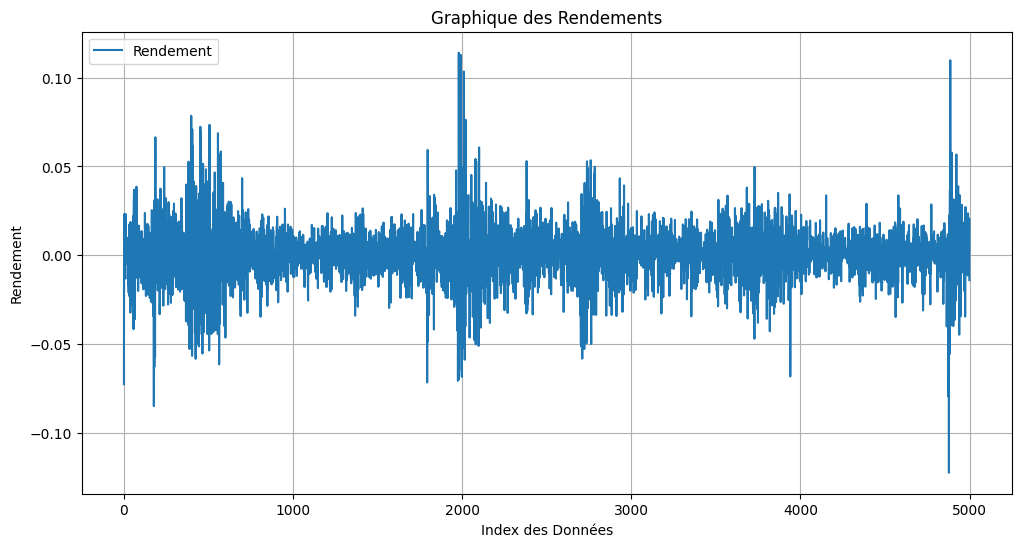

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(data['Rendement'], label='Rendement')
plt.title('Graphique des Rendements')
plt.xlabel('Index des Données')
plt.ylabel('Rendement')
plt.legend()
plt.grid(True)
plt.show()

Matrice de corrélation entre la magnitude des rendements négatifs et la volatilité:
                              Negative_Rendement_Magnitude  Volatility
Negative_Rendement_Magnitude                      1.000000    0.287799
Volatility                                        0.287799    1.000000


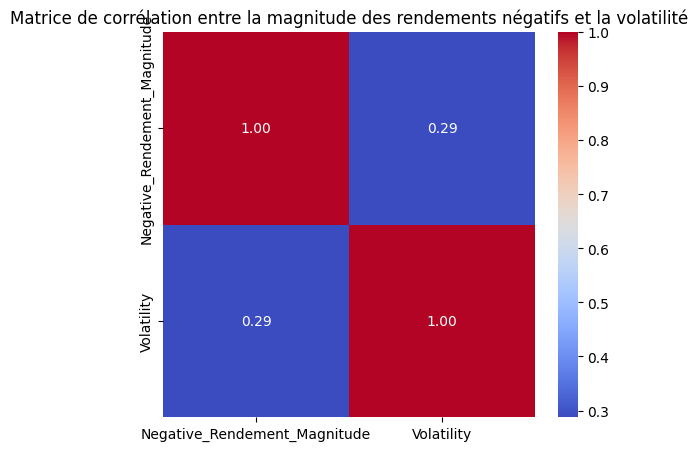

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate rolling volatility (e.g., 20-day rolling standard deviation)
data['Volatility'] = data['Rendement'].rolling(window=20).std()

# Create a column for the magnitude of negative returns
# This takes the absolute value of returns when they are negative, and 0 otherwise
data['Negative_Rendement_Magnitude'] = data['Rendement'].apply(lambda x: abs(x) if x < 0 else 0)

# Create a DataFrame with the relevant columns and drop rows with NaN values (from rolling window)
correlation_data = data[['Negative_Rendement_Magnitude', 'Volatility']].dropna()

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

print("Matrice de corrélation entre la magnitude des rendements négatifs et la volatilité:")
print(correlation_matrix)

# Plotting the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de corrélation entre la magnitude des rendements négatifs et la volatilité')
plt.show()

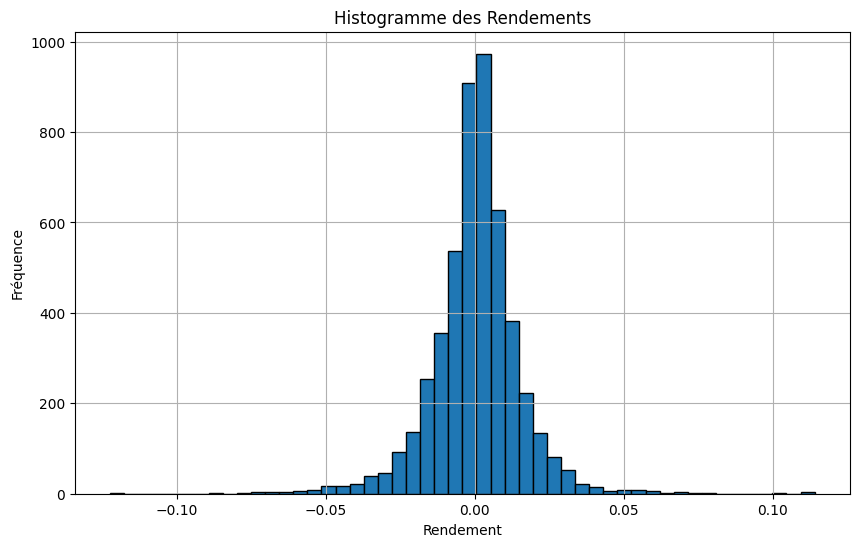

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(data['Rendement'].dropna(), bins=50, edgecolor='black')
plt.title('Histogramme des Rendements')
plt.xlabel('Rendement')
plt.ylabel('Fréquence')
plt.grid(True)
plt.show()

In [32]:
display(data.describe())

,Rendement,Rendement_futur_1,Rendement_futur_2,Target,Volatility,Negative_Rendement_Magnitude
count,5000.000000,4999.000000,4998.000000,5000.000000,4981.000000,5000.000000
mean,0.000242,0.000256,0.000252,0.483600,0.012983,0.005003
std,0.014927,0.014893,0.014891,0.499781,0.007389,0.009350
min,-0.122400,-0.122400,-0.122400,0.000000,0.002773,0.000000
25%,-0.006500,-0.006500,-0.006500,0.000000,0.008124,0.000000
50%,0.000800,0.000800,0.000800,0.000000,0.010947,0.000000
75%,0.007400,0.007400,0.007400,1.000000,0.014870,0.006500
max,0.114000,0.114000,0.114000,1.000000,0.052953,0.122400


In [34]:
def calculate_rsi(data, window=14, column='Dernier'):
    # Clean the column: remove thousands separator and replace decimal comma
    cleaned_data = data[column].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

    delta = cleaned_data.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.ewm(com=window - 1, adjust=False).mean()
    avg_loss = loss.ewm(com=window - 1, adjust=False).mean()

    # Avoid division by zero for rs calculation
    rs = avg_gain / avg_loss.replace(0, np.nan)  # Replace 0 with NaN to avoid division by zero

    rsi = 100 - (100 / (1 + rs))
    return rsi

# Calculate RSI and add it to the DataFrame
data['RSI'] = calculate_rsi(data)

# Display the last few rows with the new RSI column
print(data[['Dernier', 'RSI']].tail())

        Dernier        RSI
4995  13.033,20  55.986749
4996  12.945,38  52.681816
4997  12.974,25  53.650453
4998  13.243,43  61.553135
4999  13.057,77  54.633993


Matrice de corrélation entre le RSI et les Rendements:
                RSI  Rendement
RSI        1.000000   0.313295
Rendement  0.313295   1.000000


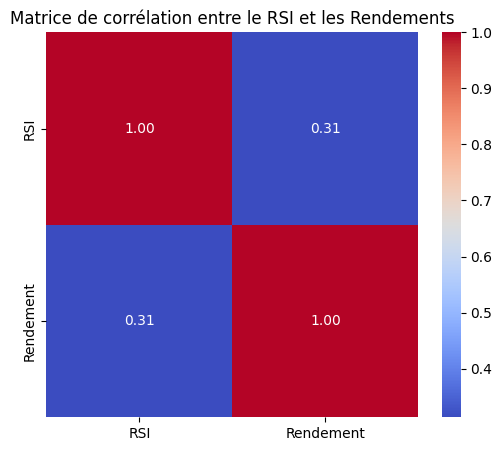

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a DataFrame with RSI and Rendement, dropping any NaN values
rsi_rendement_data = data[['RSI', 'Rendement']].dropna()

# Calculate the correlation matrix
correlation_matrix_rsi_rendement = rsi_rendement_data.corr()

print("Matrice de corrélation entre le RSI et les Rendements:")
print(correlation_matrix_rsi_rendement)

# Plotting the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix_rsi_rendement, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de corrélation entre le RSI et les Rendements')
plt.show()

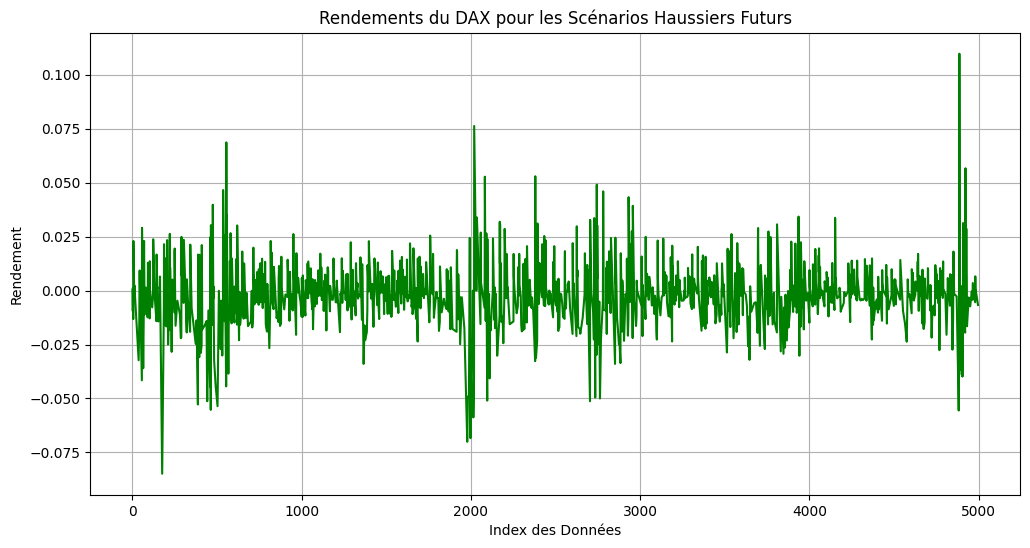

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrer les données pour les rendements futurs haussiers (tous deux positifs)
bullish_data = data[(data['Rendement_futur_1'] > 0) & (data['Rendement_futur_2'] > 0)]

plt.figure(figsize=(12, 6))
sns.lineplot(x=bullish_data.index, y='Rendement', data=bullish_data, color='green')
plt.title('Rendements du DAX pour les Scénarios Haussiers Futurs')
plt.xlabel('Index des Données')
plt.ylabel('Rendement')
plt.grid(True)
plt.show()

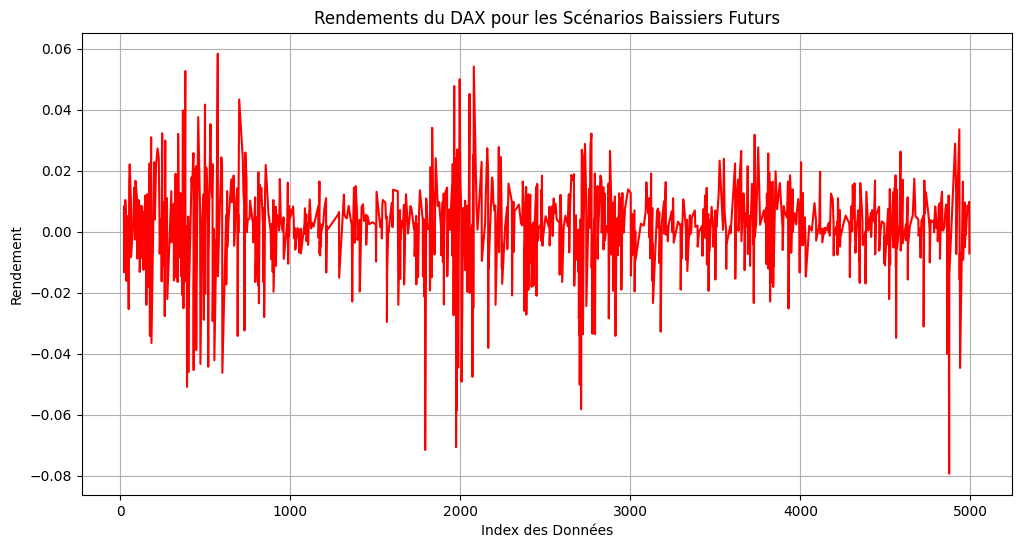

In [37]:
# Filtrer les données pour les rendements futurs baissiers (tous deux négatifs)
bearish_data = data[(data['Rendement_futur_1'] < 0) & (data['Rendement_futur_2'] < 0)]

plt.figure(figsize=(12, 6))
sns.lineplot(x=bearish_data.index, y='Rendement', data=bearish_data, color='red')
plt.title('Rendements du DAX pour les Scénarios Baissiers Futurs')
plt.xlabel('Index des Données')
plt.ylabel('Rendement')
plt.grid(True)
plt.show()